In [69]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [70]:
# read in the CSV
path = 'E:/Central Valley Fog/CV_rows_cleaned.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_rows_cleaned.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

              STATION  LATITUDE  LONGITUDE                 DATE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00   
...               ...       ...        ...                  ...   
10821797  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00   
10821798  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00   
10821799  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00   
10821800  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00   
10821801  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00   

          HourlyPrecipitation  HourlyVisibility  year  month  day  hour  \
0                         0.0            160.00  1941     12    1     0   
1                         0.0            160.

In [71]:
# read in station names CSV
path = 'E:/Central Valley Fog/station_names.csv'
if os.path.exists(path):
    station_names = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/station_names.csv'
    station_names = pd.read_csv(path, low_memory = False)

print(station_names)

     STATION_ID                                     STATION  BEGIN_DATE  \
0   USW00023155                              BAKERSFIELD AP  1927-12-31   
1   USW00093216                                   BEALE AFB  1959-06-30   
2   USI0000KC83                                       BYRON  2017-08-30   
3   USL000CQUC1                                   CARQUINEZ  2016-02-23   
4   USW00023203                                  CASTLE AFB  1941-12-31   
5   USW00093203                    CHICO ARMY FLYING SCHOOL  1942-05-05   
6   USW00023254                      CONCORD BUCHANAN FIELD  1968-12-31   
7   USL000DPXC1                   DAVIS POINT SAN PABLO BAY  2011-09-09   
8   USI0000KDLO                                 DELANO MUNI  2017-01-05   
9   USW00053125                                      FRESNO  1892-12-31   
10  USW00023167                 FRESNO CHANDLER DOWNTOWN AP  1933-04-30   
11  USW00093193                        FRESNO YOSEMITE INTL  1941-12-03   
12  USM00074917          

In [72]:
station_id_to_name = station_names.set_index('STATION_ID')['STATION']

CV_rows = CV_rows.rename(columns={'STATION': 'STATION_ID'})
CV_rows['STATION'] = CV_rows['STATION_ID'].map(station_id_to_name).fillna(CV_rows['STATION_ID'])

print(CV_rows[['STATION_ID', 'STATION']].head())

    STATION_ID      STATION
0  USM00074917  GARDNER AAF
1  USM00074917  GARDNER AAF
2  USM00074917  GARDNER AAF
3  USM00074917  GARDNER AAF
4  USM00074917  GARDNER AAF


In [73]:
# remove rows where HourlyVisibility is zero or missing
# CV_rows = CV_rows[CV_rows["HourlyVisibility"].gt(0)]

#fill in nan values in HourlyVisibility with 0
CV_rows['HourlyVisibility'] = CV_rows['HourlyVisibility'].fillna(0)

print("CV_rows:", CV_rows.shape)

CV_rows: (10821802, 12)


In [75]:
station_year_counts = CV_rows.groupby(['STATION', 'year']).size()

years_to_keep = station_year_counts[station_year_counts >= 300].index
CV_rows = CV_rows.set_index(['STATION', 'year']).loc[years_to_keep].reset_index()

print("CV_rows after dropping low-coverage station-years:", CV_rows.shape)

CV_rows after dropping low-coverage station-years: (10815684, 12)


In [68]:
# station_year_day_counts = (
#     CV_rows
#     .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
#     .groupby(['STATION', 'year'], as_index=False)
#     .size()
#     .rename(columns={'size': 'days_measured'})
# )

# stations_to_keep = (
#     station_year_day_counts
#     .groupby('STATION')['days_measured']
#     .min()
#     .loc[lambda x: x >= 300]
#     .index
# )

# stations_dropped = station_year_day_counts['STATION'].drop_duplicates().loc[
#     ~station_year_day_counts['STATION'].isin(stations_to_keep)
# ].unique()

# CV_rows = CV_rows[CV_rows['STATION'].isin(stations_to_keep)]

# print("Stations kept:", len(stations_to_keep))
# print("Stations dropped:", len(stations_dropped))
# print("CV_rows after dropping low-coverage stations:", CV_rows.shape)

Stations kept: 0
Stations dropped: 31
CV_rows after dropping low-coverage stations: (0, 12)


In [76]:
#filtering based on precipitation and visibility thresholds
CV_fog_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_fog_rows:", CV_fog_rows.shape)

CV_fog_rows: (291343, 12)


In [77]:
#counting fog days per year per station
fog_days_year = (
    CV_fog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

print(fog_days_year.head())

          STATION  year  fog_days
0  BAKERSFIELD AP  1928        12
1  BAKERSFIELD AP  1929        23
2  BAKERSFIELD AP  1930        14
3  BAKERSFIELD AP  1931        23
4  BAKERSFIELD AP  1932        16


In [78]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

19 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'WILLIAMS CAA AIRPORT']


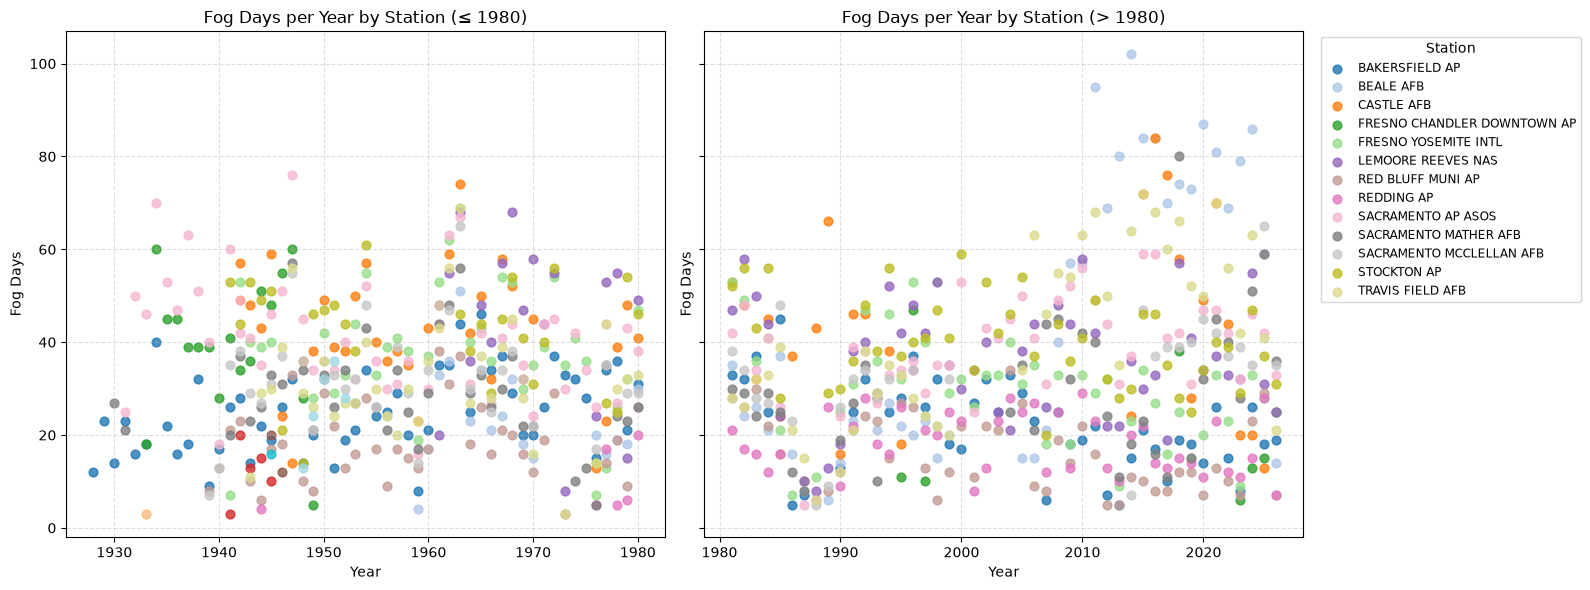

In [79]:
plot_stations = [st for st in stations_pre1970 if st in fog_days_year['STATION'].unique()]
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_stations)))
color_map = dict(zip(plot_stations, colors))

fog_pre1970 = fog_days_year[fog_days_year['STATION'].isin(plot_stations)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in plot_stations:
    station_df = fog_pre1970[fog_pre1970['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['fog_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['fog_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Fog Days per Year by Station (≤ 1980)')
axes[1].set_title('Fog Days per Year by Station (> 1980)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Fog Days')
    ax.grid(True, linestyle='--', alpha=0.4)

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

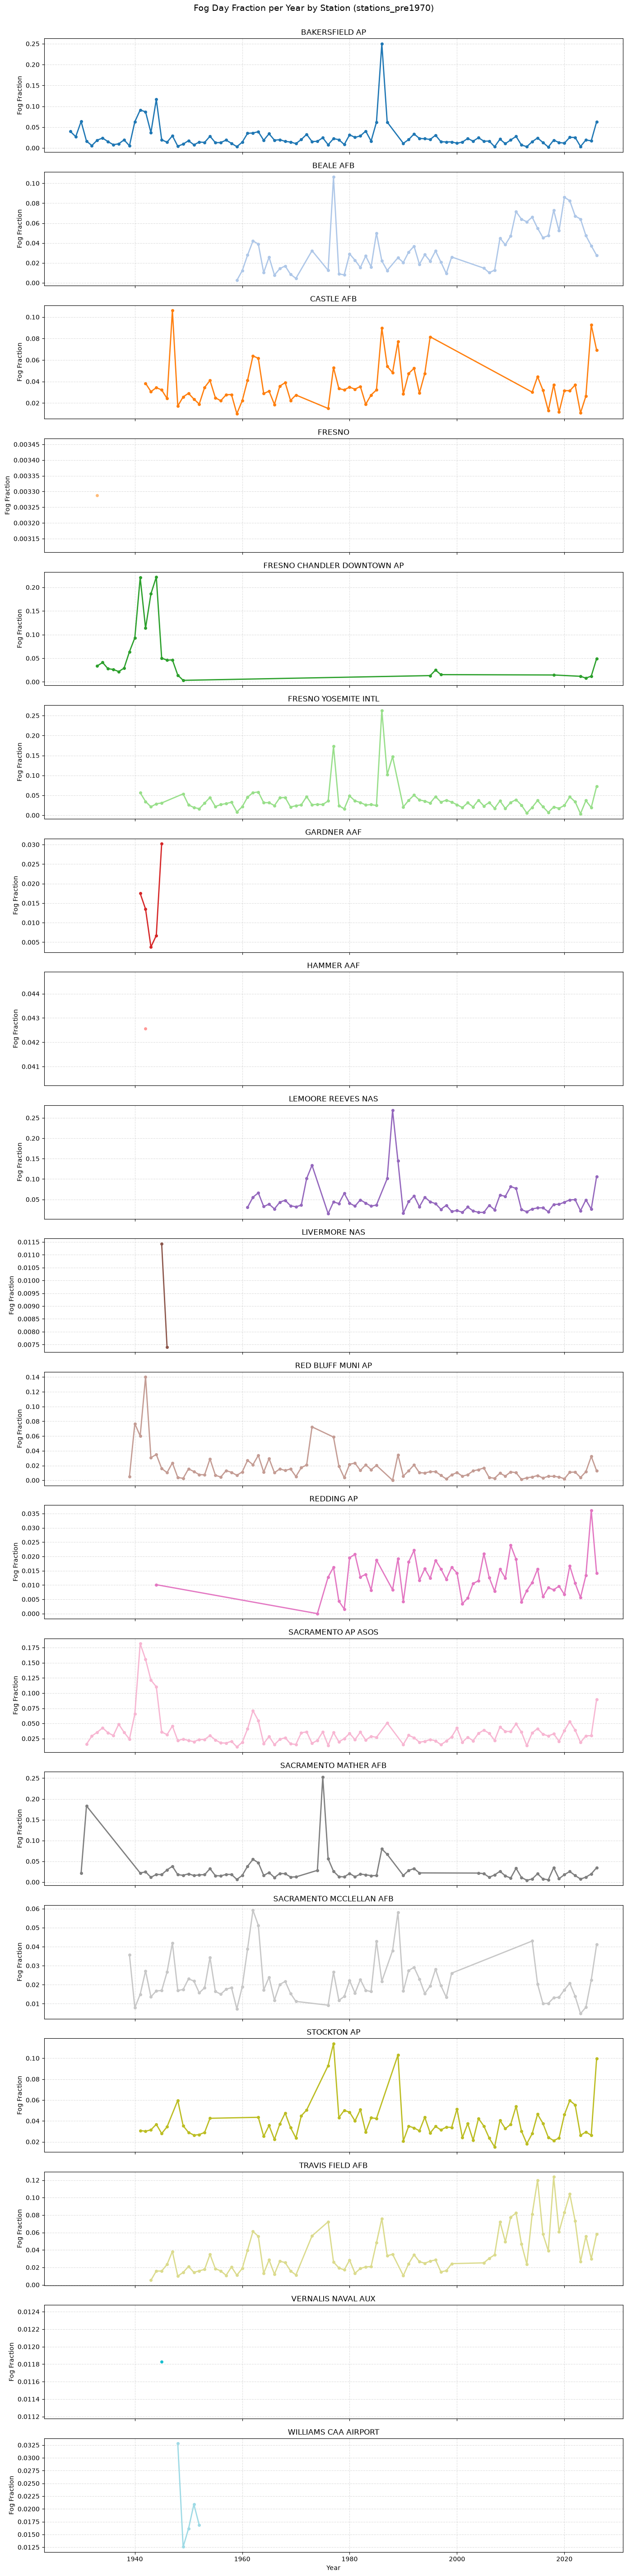

In [80]:
post1980_pre1970 = fog_days_year[
    (fog_days_year["year"] > 1980)
    & (fog_days_year["STATION"].isin(stations_pre1970))
].copy()

station_trend_stats_1980 = []

for station, station_df in post1980_pre1970.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    station_trend_stats_1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

station_trend_stats_1980 = pd.DataFrame(station_trend_stats_1980).sort_values("p_value")

print("Post-1980 fog-day trend statistics for stations_pre1970:")
print(station_trend_stats_1980[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
])

significant_post1980_pre1970 = station_trend_stats_1980[
    station_trend_stats_1980["trend_significant"]
]
print("\nStations with significant post-1980 fog-day trends:")
print(significant_post1980_pre1970[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

Post-1980 fog-day trend statistics for stations_pre1970:
                        STATION  n_obs  min_year  max_year     slope  \
1                     BEALE AFB     40      1981      2026  1.511568   
12             TRAVIS FIELD AFB     40      1981      2026  0.874916   
0                BAKERSFIELD AP     44      1981      2026 -0.310469   
6             RED BLUFF MUNI AP     43      1981      2026 -0.268463   
10     SACRAMENTO MCCLELLAN AFB     31      1981      2026  0.344166   
8            SACRAMENTO AP ASOS     43      1981      2026  0.283042   
4          FRESNO YOSEMITE INTL     45      1981      2026 -0.297751   
11                  STOCKTON AP     43      1981      2026 -0.248349   
9         SACRAMENTO MATHER AFB     34      1981      2026  0.390561   
7                    REDDING AP     44      1981      2026 -0.076094   
2                    CASTLE AFB     28      1981      2026  0.116266   
3   FRESNO CHANDLER DOWNTOWN AP      8      1995      2026 -0.181373   
5      

In [54]:
post1980_all = fog_days_year[fog_days_year["year"] > 1980].copy()

station_trend_stats_all = []

for station, station_df in post1980_all.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    station_trend_stats_all.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

station_trend_stats_all = pd.DataFrame(station_trend_stats_all).sort_values("p_value")

print("Post-1980 fog-day trend statistics for all stations:")
print(station_trend_stats_all[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
])

significant_post1980_all = station_trend_stats_all[
    station_trend_stats_all["trend_significant"]
]
print("\nStations with significant post-1980 fog-day trends (all stations):")
print(significant_post1980_all[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

Post-1980 fog-day trend statistics for all stations:
                        STATION  n_obs  min_year  max_year     slope  \
21                  STOCKTON AP     46      1981      2026  2.427382   
18        SACRAMENTO MATHER AFB     37      1981      2026  3.036759   
12                   MODESTO AP     46      1981      2026  2.356090   
5          FRESNO YOSEMITE INTL     46      1981      2026  2.400740   
17           SACRAMENTO AP ASOS     46      1981      2026  2.403207   
7            LEMOORE REEVES NAS     46      1981      2026  2.230034   
20   SACRAMENTO METROPOLITAN AP     43      1981      2026  2.573333   
0                BAKERSFIELD AP     46      1981      2026  2.223127   
15                   REDDING AP     46      1981      2026  1.640580   
22             TRAVIS FIELD AFB     41      1981      2026  1.848332   
14            RED BLUFF MUNI AP     45      1981      2026  1.672145   
23   VACAVILLE/NUT TREE AP ASOS     19      2004      2026  6.434231   
1          

In [55]:
# Filter for visibility over 100
high_visibility = CV_fog_rows[CV_fog_rows["HourlyVisibility"] > 100]

print(high_visibility)

           STATION_ID  LATITUDE  LONGITUDE                 DATE  \
620675    USW00093193   36.7800  -119.7194  1949-11-11 08:00:00   
620676    USW00093193   36.7800  -119.7194  1949-11-11 09:00:00   
620677    USW00093193   36.7800  -119.7194  1949-11-11 10:00:00   
620678    USW00093193   36.7800  -119.7194  1949-11-11 11:00:00   
620679    USW00093193   36.7800  -119.7194  1949-11-11 12:00:00   
...               ...       ...        ...                  ...   
10441898  USW00024257   40.5175  -122.2986  1990-04-30 07:00:00   
10442052  USW00024257   40.5175  -122.2986  1990-05-06 17:00:00   
10451266  USW00024257   40.5175  -122.2986  1991-05-14 11:00:00   
10451267  USW00024257   40.5175  -122.2986  1991-05-14 12:00:00   
10489270  USW00024257   40.5175  -122.2986  1995-07-03 15:00:00   

          HourlyPrecipitation  HourlyVisibility  year  month  day  hour  \
620675                    0.0             128.0  1949     11   11     8   
620676                    0.0             128